In [2]:
import numpy as np
import pandas as pd
import json
import os
import tarfile
import csv

In [3]:
os.walk('C:/Users/Louisa Zhao/Desktop/CORD/11/document_parses.tar')

<generator object _walk at 0x000001C8ECC56C10>

In [5]:
datafiles = []
for dirname,_,filenames in os.walk('C:/Users/Louisa Zhao/Desktop/CORD/11/2021-01-01/document_parses.tar'):
    for filename in filenames:
        ifile = os.path.join(dirname,filename)
        if ifile.split(".")[-1] == "json":
            datafiles.append(ifile)

# 1. Getting Citation Data

In [9]:
my_tar = tarfile.open('C:/Users/Louisa Zhao/Desktop/CORD/11/2021-01-01/document_parses.tar.gz')
filenames = my_tar.getnames()
dirfile = 'C:/Users/Louisa Zhao/Desktop/CORD/11/2021-01-01/document_parses/'
len(filenames)
dir_filedata = []

for i in range(len(filenames)):
    new_dir = dirfile + filenames[i]
    dir_filedata.append(new_dir)

print("Total data file is:" +str(len(dir_filedata)))

Total data file is:253099


In [10]:
for d in dir_filedata[:1]:
    with open(d) as f:
        data = json.load(f)
    print(data)

FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/Louisa Zhao/Desktop/CORD/11/2021-01-01/document_parses/document_parses/pdf_json/d1aafb70c066a2068b02786f8929fd9c900897fb.json'

1.1 Get all the reference data we need

In [6]:
def get_reference(dir_filedata):
    id2bib = []
    for d in dir_filedata:
        with open(d) as f:
            data = json.load(f)
        id = data['paper_id']
        title = data['metadata']['title']

        bibEntries = []
        for key,value in data['bib_entries'].items():
            refid = key
            title = value['title']
            year = value['year']
            venue = value['venue']
            try:
                DOI = value['other_ids']['DOI'][0]
            except:
                DOI = 'NA'

            bibEntries.append({'refid':refid,'title':title,'year':year,'venue':venue,'DOI':DOI})
        id2bib.append({"id":id,"bib":bibEntries,"title":title})   
    return id2bib

In [7]:
refer_json = get_reference(dir_filedata)
len(refer_json) # examine all the text data

9118

1.2 Get the paper title, reference and venue of cited paper

In [8]:
def clean_reference_info(refer_json):
    reference_node = [] #all paper and citation pairs
    cite = [] #all paper in dataset
    cited = [] #all cited paper in reference lit
    paper_info = [] #all citation and its info
    for paper in refer_json:
        self = paper['title']
        cite.append(self)
        for ref in paper['bib']:
            ref_title = ref['title']
            ref_venue = ref['venue']
            ref_year = ref['year']
            cited.append(ref_title)
            tup = (self,ref_title)
            tup_info = (self,ref_title,ref_venue,ref_year)
            reference_node.append(tup)
            paper_info.append(tup_info)
    return reference_node,cite,cited,paper_info

In [9]:
reference_node,cite,cited,paper_info = clean_reference_info(refer_json)

1.3 clean the data into csv

In [22]:
#clean reference info data into csv
def reference_info_csv(paper_info,csv_file):
    with open(csv_file,'w',encoding='utf-8',newline='') as out:
        csv_out=csv.writer(out)
        csv_out.writerow(['source','target','venue','time'])
        for row in paper_info:
            csv_out.writerow(row)

In [25]:
#clean citation pairs into csv
def paper_pair_csv(reference_node,csv_file):
    with open(csv_file,'w',encoding='utf-8',newline='') as out:
        csv_out=csv.writer(out)
        csv_out.writerow(['source','target'])
        for row in reference_node:
            csv_out.writerow(row)

# 2. Coauhtor Network

In [10]:
def get_name_info(dir_filedata):
    author_info_dict = {}
    for d in dir_filedata:
        with open(d) as f:
            data = json.load(f)
        
        name_list = data['metadata']['authors']
        for author in name_list:
            last = author['last']
            first = author['first']
            middle = ''
            if author['middle']:
                for i in author['middle']:
                    middle +=i
                    
            name = first + ' '+middle+' '+ last
            aff = author['affiliation']
            list_aff = ['NA','NA','NA','NA']
            if 'laboratory'in aff:
                list_aff[0] = aff['laboratory']
                
                if 'institution' in aff:
                    list_aff[1] = aff['institution']
                
                if 'location' in aff:
                    if 'postCode' in aff['location']:
                        list_aff[2] = aff['location']['postCode']
                        
                list_aff[3] = data['paper_id']
                
            author_info_dict[name] = list_aff
    return author_info_dict

In [70]:
author_info_dict = get_name_info(dir_filedata)
#author_info_dict

In [12]:
#get all pairs of authors
def get_coauthor(dir_filedata):
    coauthor_list = []
    for d in dir_filedata:
        with open(d) as f:
            data = json.load(f)
            
        name_list = data['metadata']['authors']
        one_paper_coauthor = []
        
        for author in name_list:
            last = author['last']
            first = author['first']
            middle = ''
            if author['middle']:
                for i in author['middle']:
                    middle +=i

            name = first + ' '+middle+' '+ last
            one_paper_coauthor.append(name)
            for i in one_paper_coauthor:
                for j in one_paper_coauthor:
                    if i != j:
                        pair=(i,j)
                        coauthor_list.append(pair)
    return coauthor_list

In [13]:
coauthor_list = get_coauthor(dir_filedata)
coauthor_list

[('Syed  Faraz', 'Ahmed  '),
 ('Ahmed  ', 'Syed  Faraz'),
 ('Syed  Faraz', 'Ahmed  '),
 ('Syed  Faraz', 'Ahmed A Quadeer'),
 ('Ahmed  ', 'Syed  Faraz'),
 ('Ahmed  ', 'Ahmed A Quadeer'),
 ('Ahmed A Quadeer', 'Syed  Faraz'),
 ('Ahmed A Quadeer', 'Ahmed  '),
 ('Syed  Faraz', 'Ahmed  '),
 ('Syed  Faraz', 'Ahmed A Quadeer'),
 ('Syed  Faraz', 'Matthew R Mckay'),
 ('Ahmed  ', 'Syed  Faraz'),
 ('Ahmed  ', 'Ahmed A Quadeer'),
 ('Ahmed  ', 'Matthew R Mckay'),
 ('Ahmed A Quadeer', 'Syed  Faraz'),
 ('Ahmed A Quadeer', 'Ahmed  '),
 ('Ahmed A Quadeer', 'Matthew R Mckay'),
 ('Matthew R Mckay', 'Syed  Faraz'),
 ('Matthew R Mckay', 'Ahmed  '),
 ('Matthew R Mckay', 'Ahmed A Quadeer'),
 ('Sung-Mok  Jung', 'Andrei R Akhmetzhanov'),
 ('Andrei R Akhmetzhanov', 'Sung-Mok  Jung'),
 ('Sung-Mok  Jung', 'Andrei R Akhmetzhanov'),
 ('Sung-Mok  Jung', 'Katsuma  Hayashi'),
 ('Andrei R Akhmetzhanov', 'Sung-Mok  Jung'),
 ('Andrei R Akhmetzhanov', 'Katsuma  Hayashi'),
 ('Katsuma  Hayashi', 'Sung-Mok  Jung'),
 ('Katsuma

In [14]:
#save coauthor pair into csv
def coauthor_pair_csv(coauthor_pair,people_csv_file):
    with open(people_csv_file,'w',encoding='utf-8',newline='') as out:
        csv_out=csv.writer(out)
        csv_out.writerow(['source','target'])
        for row in coauthor_pair:
            csv_out.writerow(row)

In [15]:
#save coauthor info into csv
def save_coauthor_info(name_info_dict,people_csv_file):
    with open(people_csv_file,'w',encoding='utf-8',newline='') as out:
        csv_out=csv.writer(out)
        csv_out.writerow(['author','laboratory','postCode','paper_id'])
        for key,values in name_info_dict.items():
            csv_out.writerow([key,values])

In [16]:
#gender info
import sys
sys.path.append(r"C:\\Users\\Louisa Zhao\\anaconda3\\Lib\\site-packages\\")
from genderize import Genderize

# 3. Build Coauthor Network

In [17]:
import networkx as nx
import sklearn #For generating some matrices
import pandas #For DataFrames
import numpy as np #For arrays
import matplotlib.pyplot as plt #For plotting
import seaborn #Makes the plots look nice

Network Degree Plot

In [67]:
def plot_degree_dist(G):
    degrees = [G.degree(n) for n in G.nodes()]
    plt.hist(degrees)
    plt.show()

In [19]:
#build coauthor network
g_coauthor = nx.Graph()
for author in coauthor_list:
    g_coauthor.add_node(author[0])
    g_coauthor.add_node(author[1])
    g_coauthor.add_edge(author[0],author[1])

In [20]:
print(nx.info(g_coauthor))

Name: 
Type: Graph
Number of nodes: 50203
Number of edges: 367402
Average degree:  14.6367


In [21]:
#caculate the network properties
coauthor_centralities = nx.degree_centrality(g_coauthor)
sorted(coauthor_centralities.items(), reverse = True, key = lambda x:x[1])
#这里要清理一遍name dict，怎么又会有乱码呢！！

[('†  ', 0.07414047249113581),
 ('Y  ', 0.020477271821839765),
 ('J  ', 0.00816700529859368),
 ('Ziad A Memish', 0.006434006613282339),
 ('Christian  Drosten', 0.0060555356360304366),
 ('Kwok-Yung  Yuen', 0.006015696585793394),
 ('Ralph S Baric', 0.005936018485319309),
 ('George F Gao', 0.005856340384845225),
 ('‡  ', 0.005796581809489661),
 ('M  ', 0.005696984183897055),
 ('Umar  Bacha', 0.005657145133660013),
 ('Hadi  Danawi', 0.005657145133660013),
 ('Florian  Fischer', 0.005657145133660013),
 ('Farshad  Pourmalek', 0.005657145133660013),
 ('Gholamreza  Roshandel', 0.005657145133660013),
 ('Mohammad Ali Sahraian', 0.005657145133660013),
 ('Akio  Adachi', 0.0056372256085414916),
 ('Pakistan  Karachi', 0.0053583522568821955),
 ('I D ', 0.005258754631289589),
 ('Shibo  Jiang', 0.005218915581052547),
 ('Raghib  Ali', 0.005218915581052547),
 ('Walid  Ammar', 0.005218915581052547),
 ('Rajaa  Al-Raddadi', 0.005218915581052547),
 ('Alaa  Badawi', 0.0051989960559340265),
 ('Mohamed  Al-Thani

In [101]:
#remove the node the centrality is too small
#g_coauthor.remove_edges_from([(n1, n2) for n1, n2, d in g_coauthor.edges(data = True) if d['centrailities'] <= 25])

The distrubution of degree centrality is:

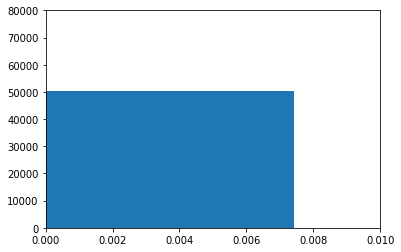

In [22]:
plt.hist(list(coauthor_centralities.values()))
plt.axis([0, 0.010,0, 80000])
plt.show()

community detection using modularity

In [23]:
from networkx.algorithms.community import greedy_modularity_communities
cc = list(greedy_modularity_communities(g_coauthor))

In [77]:
print("We have detect the number of community is :" + str(len(cc)))

We have detect the number of community is :2935


In [75]:
print("We have detect the number of nodes in the first community is :" + str(len(cc[0])))

We have detect the number of nodes in the first community is :6147


In [24]:
cc[0]

frozenset({'Si-Yang  Huang',
           'Huiming  Luo',
           'Ng  Fai',
           'Dang  Wang',
           '•  Desterio Ouma',
           'Daniel C Pevear',
           'Pei  Zhang',
           'Zi-Wei  Ye',
           'Michael H Lehmann',
           'Dian  Jiao',
           'Yongfeng  Li',
           'Xi  Chen',
           'Weizao  Chen',
           'Wang S Wang',
           'Li  Shasha',
           'Yan  2☯',
           'Si L Meng',
           'H  Xu',
           'John V Moran',
           'Zhou D ',
           'Junchao  Shi',
           'Zhou X Zhang',
           'Enbo  Cui',
           'Xiaoguang  Zhang',
           'Qiurui  Id',
           'Yunchao  Kan',
           'Jörg  Kinne',
           'Shujuan  Du',
           'Hao  Yan',
           'Peng Q ',
           'Chuanmin  Liu',
           'Chunnan  Liang',
           'Huwen  Wang',
           'Muhammad  Mahmood Mukhtar',
           'Shuxian  Xia',
           'Xin  Tan',
           'Ying  Liu',
           'Ying  Yang',
      

1) look at the author properities of community 1

In [74]:
for i in cc[0]:
    ins = author_info_dict[i][1]
    if ins != 'NA':
        print(author_info_dict[i][1])

Huazhong Agricultural University
University of Illinois at Chicago
The University of Hong Kong
National Institutes of Health
The First Affiliated Hospital of Guangzhou Medical University
Jilin University
Sichuan Agricultural University
Central South University
National Institutes for Food and Drug Control
Wuhan University
Huazhong Agricultural University
Beijing University of Chinese Medicine
Southern Medical University
Chinese Academy of Sciences
Northeast Agricultural University
Central South University

Northeast Agricultural University
University of Saskatchewan



Sichuan Agricultural University
Jiangxi Agricultural University
Chinese Academy of Sciences
Tsinghua University
Henan Agricultural University
Chinese Academy of Sciences
Nanjing Agricultural University
University of Illinois at Chicago
Capital Medical University
University of Minnesota
Nankai University
Nanjing Agricultural University
University of Southampton
South China University of Technology
The University of Hong K

Nankai University

Huazhong Agricultural University
Nanjing Medical University

Zhongnan Hospital of Wuhan University
Chinese Academy of Agricultural Sciences
Heilongjiang Bayi Agricultural University
University of Minnesota Medical School
Wenzhou Medical University
CSIRO Animal, Food and Health Sciences
Wuhan University
University of Minnesota
Central South University
The Chinese Academy of Agricultural Sciences
University of Macau
Australian Animal Health Laboratory
Sichuan Agricultural University
Kunming Yunnan
Huazhong Agricultural University
Union Medical College
Zhejiang University
Luoyang Orthopedic Hospital of Henan Province
The University of Illinois at Chicago

the First Affiliated Hospital of Guangzhou Medical University
China Agricultural University
Guangdong Laboratory Animals Monitoring Institute
University of Maryland
Chinese Academy of Medical Sciences
Nanjing Agricultural University
Northeast Agricultural University
Northeast Agricultural University
Capital Medical Uni

In [78]:
for i in cc[1]:
    ins = author_info_dict[i][1]
    if ins != 'NA':
        print(author_info_dict[i][1])

Johns Hopkins Bloomberg School of Public Health
National Institutes of Health
University of Maryland
GeneOne Life Science Inc
Wellcome Trust Centre for Human Genetics
National Institute of Hygiene and Epidemiology
University of Maryland
Wellcome Trust Major Overseas Program
ORCRB
University of Maryland
Jagiellonian University
University of North Carolina
University of Iowa


Global Phasing Ltd
Kenya Medical Research Institute (KEMRI) -Wellcome Trust Research Collaborative Programme
University of Oxford
Qatar University
Laval University
Jagiellonian University
University of Wisconsin-Madison

Georgia Emerging Infections Program and the Atlanta Research and Education Foundation
Jagiellonian University
Public Health England

University of Sarajevo
Erasmus MC-Sophia Children's Hospital
University of North Carolina

Max Planck Institute of Colloids and Interfaces
Pacific Northwest National Laboratory
University of Edinburgh
University of Wisconsin-Madison (UW-Madison)
National Institutes of

Erasmus Medical Center
Vitalant Research Institute
Emory University
Northern Border University
University of Washington

Johns Hopkins Bloomberg School of Public Health
Université Catholique de Louvain
China Medical University
University of California
University of Milan
University of Glasgow
Chulalongkorn University
Hokkaido University
Columbia University
University of Wisconsin at Madison
University of Saskatchewan
Columbia University
The Pirbright Institute
KEMRI Centre for Geographic Medicine Research -Coast
Erasmus MC
Jagiellonian University
Jamal Mohamed College
Nagasaki University
National University Hospital
University of Veterinary Medicine
Kimron Veterinary Institute
The Wistar Institute
German Primate Center-Leibniz Institute for Primate Research
Oxford University Clinical Research Unit
University of Oxford
Hokkaido University
Hokkaido University
Silesian Center for Heart Diseases

University of Western Australia
National Institute of Allergy and Infectious Diseases
Blood Sy

National Institutes of Health
North Carolina State University
NIAID/NIH
Columbia University
National Institutes of Health
McMaster University

Muhimbili Research Centre
Vanderbilt University Medical Center
Centre National de la Recherche Scientifique and Université de la Méditerranée
RMIT University
University of Barcelona
Berlin Institute of Health

Baltimore County
University of Amsterdam
University of California Irvine
National Institute of Biomedical Research
Utrecht University
University of California
IRCCS
Erasmus Medical Center

Nagasaki University
Duke University
Jazan University
SRI International
German Primate Center-Leibniz Institute for Primate Research
Université Catholique de Louvain
Armed Forces Research Institute of Medical Sciences
COMSATS Institute of Information Technology
University of Lü beck
CureVac AG
Leiden University
Institut universitaire de cardiologie et pneumologie de Québec
University Health Network
University of Manitoba
Wellcome Trust Major Overseas Prog

Look at the institute of collaboration

In [53]:
def get_institute(dir_filedata):
    total_ins = []
    for d in dir_filedata:
        with open(d) as f:
            data = json.load(f)

        aff_list = []
        for author in data['metadata']['authors']:
            if author['affiliation']:
                aff = author['affiliation']['institution']
                aff_list.append(aff)
        #bring list as a tuple of biparti network
        for i in aff_list:
            for j in aff_list:
                if i != '' and j !='':
                    col = (i,j)
                    total_ins.append(col)
    return total_ins

In [54]:
total_inst_list = get_institute(dir_filedata)
total_inst_list

[('Hokkaido University', 'Hokkaido University'),
 ('The Hong Kong University of Science and Technology',
  'The Hong Kong University of Science and Technology'),
 ('The Hong Kong University of Science and Technology',
  'The Hong Kong University of Science and Technology'),
 ('The Hong Kong University of Science and Technology',
  'The Hong Kong University of Science and Technology'),
 ('The Hong Kong University of Science and Technology',
  'The Hong Kong University of Science and Technology'),
 ('The Hong Kong University of Science and Technology',
  'The Hong Kong University of Science and Technology'),
 ('The Hong Kong University of Science and Technology',
  'The Hong Kong University of Science and Technology'),
 ('The Hong Kong University of Science and Technology',
  'The Hong Kong University of Science and Technology'),
 ('The Hong Kong University of Science and Technology',
  'The Hong Kong University of Science and Technology'),
 ('The Hong Kong University of Science and Tech

In [55]:
print("total pairs of institute of collaboration:",len(total_inst_list))

total pairs of institute of collaboration: 351589


Next question: who are more likely to work together during the pandemic?

# 4. Build paper and reference network

In [56]:
g_paper = nx.Graph()
for paper in reference_node:
    g_paper.add_node(paper[0])
    g_paper.add_node(paper[1])
    g_paper.add_edge(paper[0],paper[1])

In [57]:
print(nx.info(g_paper))

Name: 
Type: Graph
Number of nodes: 353535
Number of edges: 499723
Average degree:   2.8270


In [114]:
paper_centralities = nx.degree_centrality(g_paper)
sorted(paper_centralities.items(), reverse = True, key = lambda x:x[1])[:100]

[('Submit your next manuscript to BioMed Central and take full advantage of: • Convenient online submission • Thorough peer review • No space constraints or color figure charges • Immediate publication on acceptance • Inclusion in PubMed, CAS, Scopus and Google Scholar • Research which is freely available for redistribution',
  0.06968951132988987),
 ('This article is an open access article distributed under the terms and conditions of the Creative Commons Attribution license',
  0.016570180608035497),
 ('Prostate-specific antigen modulates genes involved in bone remodeling and induces osteoblast differentiation of human osteosarcoma cell line SaOS-2',
  0.00917484198241296),
 ('In silico gene function prediction using ontology-based pattern identification',
  0.0059047156838954945),
 ('Design and modification of EGF4KDEL 7Mut, a novel bispecific ligand-directed toxin, with decreased immunogenicity and potent anti-mesothelioma activity',
  0.005662056135242255),
 ('Efficient selection 

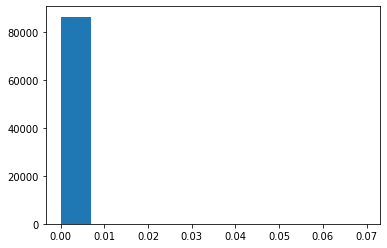

In [116]:
plt.hist(list(paper_centralities.values()))
plt.show()

# 5. Build Institute Network

In [58]:
g_institute = nx.Graph()
for ins in total_inst_list:
    g_institute.add_node(ins[0])
    g_institute.add_node(ins[1])
    g_institute.add_edge(ins[0],ins[1])

In [59]:
print(nx.info(g_institute))

Name: 
Type: Graph
Number of nodes: 4967
Number of edges: 16577
Average degree:   6.6749


Institute Centralities Measure

In [60]:
ins_centralities = nx.degree_centrality(g_institute)
sorted(ins_centralities.items(), reverse = True, key = lambda x:x[1])[:100]

[('Chinese Academy of Sciences', 0.034232782923882404),
 ('University of California', 0.02517116391461941),
 ('University of Oxford', 0.022754732178815948),
 ('National Institutes of Health', 0.022553362867498993),
 ('University of Cambridge', 0.02194925493354813),
 ('University of Toronto', 0.01852597664115989),
 ('Ministry of Health', 0.01852597664115989),
 ('United States of America', 0.016915022150624244),
 ('University of Washington', 0.015304067660088603),
 ('Mahidol University', 0.015102698348771648),
 ('The University of Hong Kong', 0.014699959726137737),
 ('Institut Pasteur', 0.01369311316955296),
 ('Imperial College London', 0.013491743858236005),
 ('Utrecht University', 0.013491743858236005),
 ('University College London', 0.01329037454691905),
 ('University of Amsterdam', 0.013089005235602094),
 ('University of Glasgow', 0.013089005235602094),
 ('Fudan University', 0.012283527990334274),
 ('University of Bern', 0.012283527990334274),
 ('University of Minnesota', 0.012082158

Institute degree measure

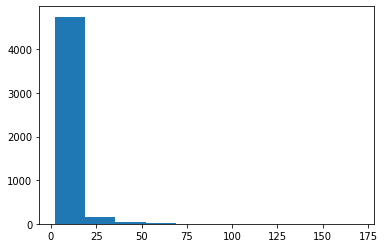

In [65]:
degrees = [g_institute.degree(n) for n in g_institute.nodes()]
plt.hist(degrees)
plt.
plt.show()